In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_110.jpeg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_1079.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_585.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_825.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_630.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_1114.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_163.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique/bouteille_plastique_430.jpg
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/B

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader

In [47]:
# Explore the dataset directory

import os

for dirname, dirnames, filenames in os.walk("/kaggle/input"):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/manonstr
/kaggle/input/datasets/manonstr/tipe-webscraping
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Bouteille_plastique
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Emballage_metallique
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Papier_Carton
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Brique_en_carton
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Verre
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement/Ordure_m�nag�re
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/test
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/test/Bouteille_plastique
/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/test/Emballage_metallique
/kaggle/input/datasets/manonstr/tipe

In [48]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

train_path = "/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/entrainement"

test_path = "/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/test"

In [49]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [50]:
train_dataset = ImageFolder(
    root=train_path,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=test_path,
    transform=train_transform
)

In [51]:
print("Classes:")
print(train_dataset.classes)

print()

print("Class Mapping:")
print(train_dataset.class_to_idx)

print()

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Classes:
['Bouteille_plastique', 'Brique_en_carton', 'Emballage_metallique', 'Ordure_m�nag�re', 'Papier_Carton', 'Verre']

Class Mapping:
{'Bouteille_plastique': 0, 'Brique_en_carton': 1, 'Emballage_metallique': 2, 'Ordure_m�nag�re': 3, 'Papier_Carton': 4, 'Verre': 5}

Training Images: 7019
Testing Images: 157


In [52]:
image, label = train_dataset[0]

print(type(image))
print(type(label))

print(image.shape)

print(label)

<class 'torch.Tensor'>
<class 'int'>
torch.Size([3, 224, 224])
0


In [53]:
print(image.min())
print(image.max())

tensor(-2.0837)
tensor(2.5877)


In [54]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [55]:
images, labels = next(iter(train_loader))

In [56]:
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [57]:
print(labels[:10])

tensor([2, 5, 2, 0, 4, 0, 2, 4, 4, 1])


In [58]:
print(len(train_loader))

220


In [59]:
### Create a Visualization Transform
visual_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [60]:
## Create a Visualization Dataset
visual_dataset = ImageFolder(
    root=train_path,
    transform=visual_transform
)

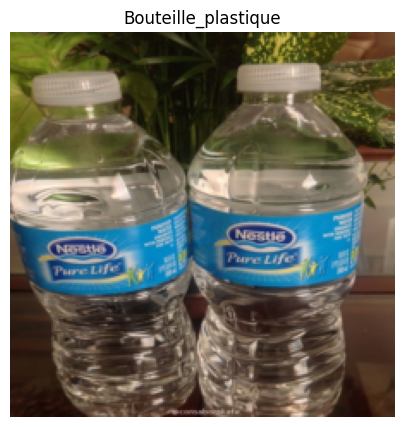

In [61]:
image, label = visual_dataset[80]

plt.figure(figsize=(5,5))
plt.imshow(image.permute(1,2,0))
plt.title(visual_dataset.classes[label])
plt.axis("off")
plt.show()

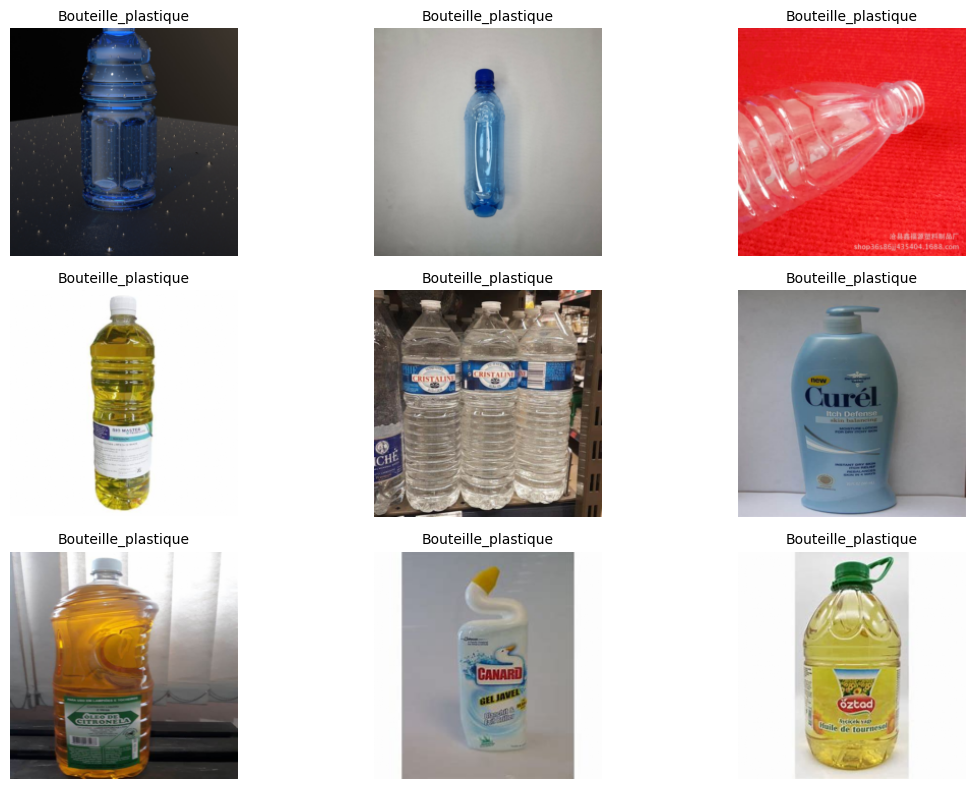

In [62]:
plt.figure(figsize=(12,8))

for i in range(9):
    image, label = visual_dataset[i]

    plt.subplot(3,3,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(visual_dataset.classes[label], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
### Count Images Per Class
from collections import Counter

labels = [label for _, label in visual_dataset]

class_counts = Counter(labels)

for idx, count in class_counts.items():
    print(f"{visual_dataset.classes[idx]} : {count}")

Bouteille_plastique : 1437
Brique_en_carton : 1047
Emballage_metallique : 1217
Ordure_m�nag�re : 1050
Papier_Carton : 1043
Verre : 1225


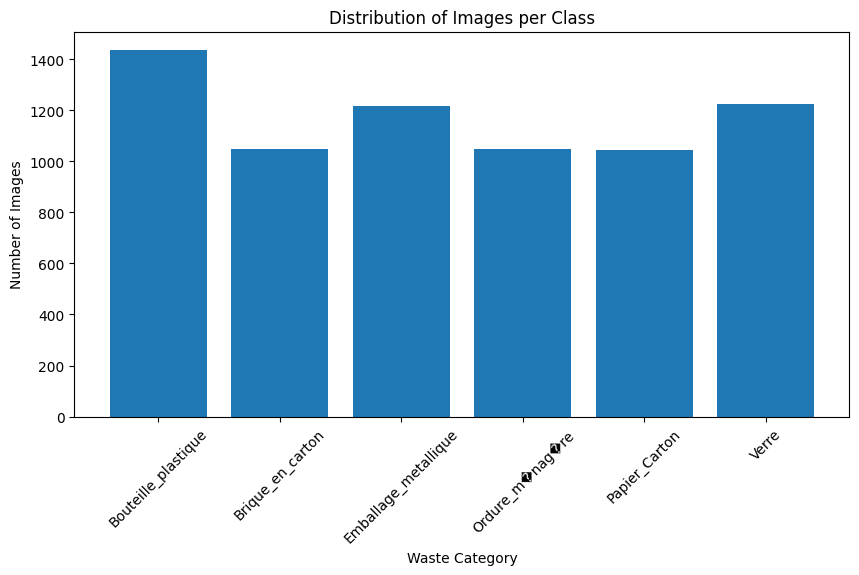

In [64]:
###Plot Class Distribution
class_names = list(class_counts.keys())
counts = list(class_counts.values())

class_names = [visual_dataset.classes[i] for i in class_names]

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.xticks(rotation=45)
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Distribution of Images per Class")

plt.show()

****Load ResNet50****

In [65]:
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [66]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [67]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [68]:
import torch.nn as nn

model.fc = nn.Linear(
    in_features=2048,
    out_features=6
)

In [69]:
for param in model.parameters():
    param.requires_grad = False

In [70]:
for param in model.fc.parameters():
    param.requires_grad = True

In [71]:
trainable = 0

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)
        trainable += 1

print("Trainable Parameters:", trainable)

fc.weight
fc.bias
Trainable Parameters: 2


In [72]:
import torch.nn as nn
criterion = nn.CrossEntropyLoss()

In [73]:
print(criterion)

CrossEntropyLoss()


In [74]:
import torch.optim as optim
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [75]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [76]:
images, labels = next(iter(train_loader))

outputs = model(images)

print(outputs.shape)

torch.Size([32, 6])


In [77]:
print(outputs)

tensor([[-0.1659, -0.0226,  0.1597,  0.1240,  0.2029, -0.1994],
        [ 0.0981,  0.2985,  0.0369,  0.1063, -0.1007, -0.0076],
        [ 0.1974, -0.0023, -0.0515,  0.2947,  0.0750,  0.0836],
        [ 0.2489,  0.2426, -0.0189,  0.0835,  0.1190,  0.1568],
        [ 0.1566,  0.1240,  0.0880,  0.3428,  0.0460,  0.1373],
        [ 0.0131,  0.0498, -0.1692,  0.0352,  0.0634,  0.0110],
        [ 0.1156,  0.0201, -0.2015,  0.1025,  0.1226, -0.3776],
        [ 0.1145,  0.0663, -0.0220,  0.0977,  0.1156, -0.0599],
        [ 0.0852, -0.0503,  0.0191,  0.1876, -0.0112,  0.0669],
        [ 0.1215,  0.0676,  0.3245,  0.0045, -0.0379, -0.0020],
        [ 0.3509,  0.1097,  0.0905,  0.0749,  0.0149,  0.0163],
        [ 0.0207,  0.0259,  0.2574, -0.1786,  0.1314,  0.1999],
        [ 0.1208,  0.4015,  0.2920,  0.2144,  0.0100, -0.1031],
        [ 0.0155,  0.0877, -0.0344,  0.0044,  0.0448, -0.1483],
        [ 0.1445, -0.0449, -0.0596,  0.2254, -0.1218,  0.0968],
        [ 0.2370, -0.0340,  0.2227,  0.2

In [78]:
predictions = torch.argmax(outputs, dim=1)

print(predictions)

tensor([4, 1, 3, 0, 3, 4, 4, 4, 3, 2, 0, 2, 1, 1, 3, 0, 3, 5, 0, 1, 3, 4, 5, 0,
        1, 1, 4, 0, 0, 4, 4, 3])


In [79]:
print("Predicted :", predictions[:10])
print("Actual    :", labels[:10])

Predicted : tensor([4, 1, 3, 0, 3, 4, 4, 4, 3, 2])
Actual    : tensor([4, 0, 1, 2, 1, 4, 3, 1, 0, 5])


In [80]:
print(next(model.parameters()).device)

cpu


In [81]:
model = model.to(device)

In [82]:
print(next(model.parameters()).device)

cuda:0


In [83]:
print(images.device)
print("Labels Device:", labels.device)

cpu
Labels Device: cpu


In [84]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [85]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/5] Loss: 0.4570
Epoch [2/5] Loss: 0.1482
Epoch [3/5] Loss: 0.1025
Epoch [4/5] Loss: 0.0828
Epoch [5/5] Loss: 0.0673


In [86]:
from torchvision.datasets import ImageFolder

test_path = "/kaggle/input/datasets/manonstr/tipe-webscraping/1024+/test"

test_dataset = ImageFolder(
    root=test_path,
    transform=train_transform
)

In [87]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [88]:
print("Number of test images:", len(test_dataset))
print("Classes:", test_dataset.classes)

Number of test images: 157
Classes: ['Bouteille_plastique', 'Brique_en_carton', 'Emballage_metallique', 'Ordure_m�nag�re', 'Papier_Carton', 'Verre']


In [89]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Predicted class
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        correct += (predicted == labels).sum().item()

        # Count total images
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Correct Predictions : {correct}")
print(f"Total Images        : {total}")
print(f"Test Accuracy       : {accuracy:.2f}%")

Correct Predictions : 114
Total Images        : 157
Test Accuracy       : 72.61%
